# SHAP解析と逆解析デモ：材料・化学データへの応用
**このnotebookで学ぶこと：**
- SHAPによるモデルの局所・大域解釈
- Waterfall / Beeswarm / Dependence plotの読み方
- 多重共線性がSHAP値に与える影響
- `scipy.optimize`を使った組成制約つき逆解析
- GPRの不確実性σを使った外挿リスクの制御

## 0. ライブラリのインストール・インポート

In [1]:
# !pip install shap pymoo --break-system-packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
import shap
from scipy.optimize import minimize

print("shap version:", shap.__version__)

shap version: 0.49.1


## 1. デモデータの生成
前の記事（小データ機械学習）と同じFe/Ni/Cr合金の引張強度データ（n=80）を使用します。

In [2]:
np.random.seed(42)
n = 80

# 組成（合計100%になるようにサンプリング）
Ni   = np.random.uniform(5, 35, n)
Cr   = np.random.uniform(2, 18, n)
Fe   = 100 - Ni - Cr  # 閉包制約

temp    = np.random.uniform(800, 1200, n)   # 熱処理温度 (°C)
time    = np.random.uniform(1, 10, n)        # 保持時間 (h)
cool_r  = np.random.uniform(1, 50, n)        # 冷却速度 (°C/min)

# 目的変数：引張強度 (MPa)
y = (200
     + 3.5 * Ni
     - 0.8 * Cr
     + 0.12 * temp
     + 10 * np.log1p(time)
     - 0.5 * cool_r
     + 0.002 * temp * Ni   # 交互作用項
     + np.random.normal(0, 10, n))

df = pd.DataFrame({
    'Fe': Fe, 'Ni': Ni, 'Cr': Cr,
    'temp': temp, 'time': time, 'cool_r': cool_r,
    'tensile_strength': y
})

print(df.shape)
df.describe().round(2)

(80, 7)


,Fe,Ni,Cr,temp,time,cool_r,tensile_strength
count,80.00,80.00,80.00,80.00,80.00,80.00,80.00
mean,71.21,18.98,9.81,994.63,5.80,25.33,421.72
std,10.55,9.17,4.63,113.62,2.69,14.37,53.02
min,51.60,5.17,2.11,802.02,1.14,1.71,329.39
25%,62.40,10.53,5.96,893.82,3.65,14.32,379.22
50%,71.37,18.08,9.87,1016.90,5.87,26.69,413.90
75%,79.36,27.25,14.11,1076.47,8.21,37.31,461.35
max,90.52,34.61,17.77,1189.20,9.91,49.53,532.55



> **⚠️ 今回のデモについて（組成の閉包制約）**  
> Fe = 100 − Ni − Cr のため、Fe・Ni・Crの3変数を同時に特徴量に入れると構造的多重共線性が生じます。  
> このノートブックでは「3変数を入れると何が起きるか」を実際に見るための**意図的な設定**です。  
> 実務では、冗長な変数を除く（FeをDropし Ni・Crのみ使う）か、CLR変換（CoDA）で対処することを推奨します。

## 2. 相関分析：特徴量選択の前に多重共線性を確認する

モデルを作る前に特徴量間の相関を確認します。強く相関する特徴量が複数あると、後のSHAP解釈で重要度が分散し、真の支配因子が見えにくくなります（Section 6で実演）。

**確認すること：**
- 相関行列（ヒートマップ）：|r| > 0.8 程度が要注意
- VIF（分散拡大係数）：VIF > 10 が除外・統合の目安

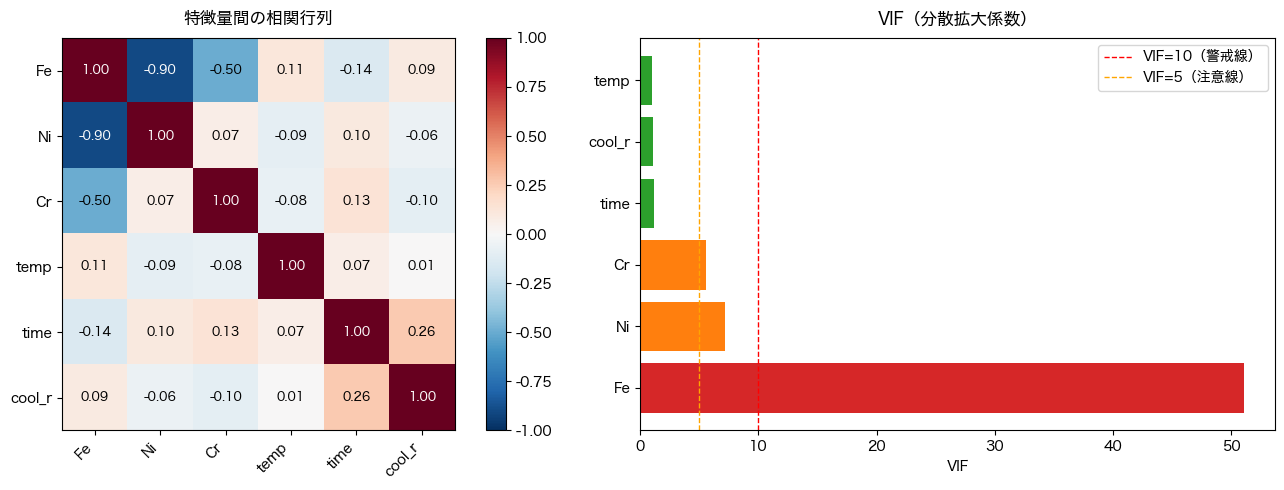

feature   VIF
     Fe 51.14
     Ni  7.13
     Cr  5.55
   time  1.12
 cool_r  1.10
   temp  1.02

→ VIF < 5：問題なし　VIF 5〜10：注意　VIF > 10：除外・統合を検討


In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

feature_cols = ['Fe', 'Ni', 'Cr', 'temp', 'time', 'cool_r']
X_df = df[feature_cols]

# ── 相関行列のヒートマップ ──
corr = X_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(feature_cols)))
axes[0].set_yticks(range(len(feature_cols)))
axes[0].set_xticklabels(feature_cols, rotation=45, ha='right')
axes[0].set_yticklabels(feature_cols)
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        axes[0].text(j, i, f'{corr.values[i, j]:.2f}',
                     ha='center', va='center', fontsize=9,
                     color='white' if abs(corr.values[i, j]) > 0.6 else 'black')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('特徴量間の相関行列', pad=10)

# ── VIF ──
vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_df.values, i) for i in range(len(feature_cols))]
}).sort_values('VIF', ascending=False)

colors = ['#d62728' if v > 10 else '#ff7f0e' if v > 5 else '#2ca02c'
          for v in vif_data['VIF']]
axes[1].barh(vif_data['feature'], vif_data['VIF'], color=colors)
axes[1].axvline(x=10, color='red', linestyle='--', linewidth=1.0, label='VIF=10（警戒線）')
axes[1].axvline(x=5,  color='orange', linestyle='--', linewidth=1.0, label='VIF=5（注意線）')
axes[1].set_xlabel('VIF')
axes[1].set_title('VIF（分散拡大係数）', pad=10)
axes[1].legend()

plt.tight_layout()
plt.show()

print(vif_data.round(2).to_string(index=False))
print("\n→ VIF < 5：問題なし　VIF 5〜10：注意　VIF > 10：除外・統合を検討")

## 3. モデルの訓練
Random Forest（TreeExplainer用）とGPR（不確実性定量化用）の2種類を訓練します。

In [4]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_predict

feature_cols = ['Fe', 'Ni', 'Cr', 'temp', 'time', 'cool_r']
X = df[feature_cols].values
y_arr = df['tensile_strength'].values

# ── Random Forest ──
rf = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
rf.fit(X, y_arr)

loo = LeaveOneOut()
y_pred_rf = cross_val_predict(rf, X, y_arr, cv=loo)
r2_rf  = r2_score(y_arr, y_pred_rf)
mae_rf = np.abs(y_arr - y_pred_rf)

# ── GPR ──
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
gpr.fit(X_sc, y_arr)

gpr_pipe = Pipeline([('sc', StandardScaler()),
                     ('gpr', GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3, random_state=42))])
y_pred_gpr = cross_val_predict(gpr_pipe, X, y_arr, cv=loo)
r2_gpr  = r2_score(y_arr, y_pred_gpr)
mae_gpr = np.abs(y_arr - y_pred_gpr)

model_names = ['RF (max_depth=4)', 'GPR']
r2_scores   = [r2_rf,  r2_gpr]
mae_means   = [mae_rf.mean(),  mae_gpr.mean()]
mae_stds    = [mae_rf.std(),   mae_gpr.std()]

print("--- モデル比較結果 (LOOCV) ---")
for name, r2, mae_m, mae_s in zip(model_names, r2_scores, mae_means, mae_stds):
    print(f"  {name:20s}  LOOCV R²: {r2:.3f}  MAE: {mae_m:.1f} ± {mae_s:.1f} MPa")


--- モデル比較結果 (LOOCV) ---
  RF (max_depth=4)      LOOCV R²: 0.896  MAE: 13.3 ± 10.5 MPa
  GPR                   LOOCV R²: 0.967  MAE: 7.6 ± 5.8 MPa


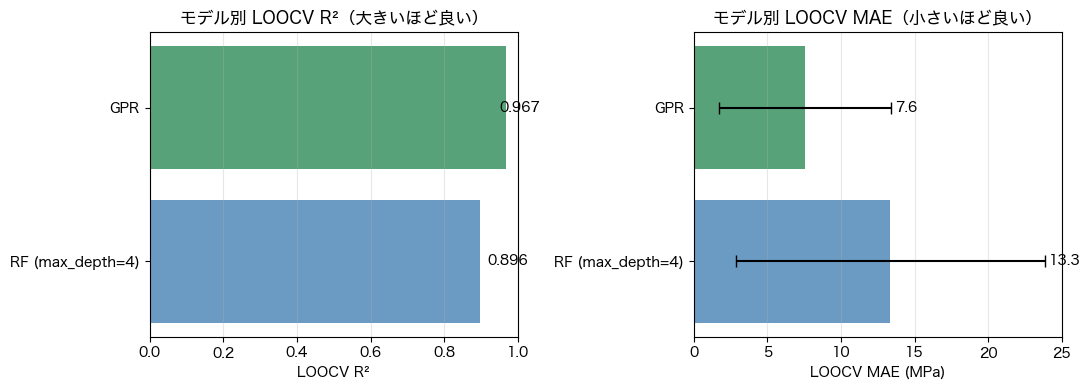

In [5]:
# LOOCV R² / MAE の棒グラフ比較
colors = ['steelblue', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 左：R²
ax = axes[0]
ax.barh(model_names, r2_scores, color=colors, alpha=0.8)
ax.set_xlabel("LOOCV R²")
ax.set_title("モデル別 LOOCV R²（大きいほど良い）")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3, axis='x')
for i, score in enumerate(r2_scores):
    ax.text(min(score + 0.02, 0.95), i, f"{score:.3f}", va='center', fontsize=10)

# 右：MAE
ax = axes[1]
ax.barh(model_names, mae_means, xerr=mae_stds, color=colors, capsize=4, alpha=0.8)
ax.set_xlabel("LOOCV MAE (MPa)")
ax.set_title("モデル別 LOOCV MAE（小さいほど良い）")
ax.grid(True, alpha=0.3, axis='x')
for i, (m, s) in enumerate(zip(mae_means, mae_stds)):
    ax.text(m + s + 0.3, i, f"{m:.1f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()


In [6]:
# SHAP値の計算（Beeswarm・Dependence・Waterfallで共通して使用）
explainer = shap.TreeExplainer(rf)
X_df = pd.DataFrame(X, columns=feature_cols)
shap_values = explainer(X_df, check_additivity=False)

print(f"Base value（平均予測値）: {float(explainer.expected_value):.1f} MPa")
print(f"SHAP値の形状: {shap_values.values.shape}（サンプル数 × 特徴量数）")

Base value（平均予測値）: 421.6 MPa
SHAP値の形状: (80, 6)（サンプル数 × 特徴量数）


## 4. SHAP大域解釈：Beeswarm plot

**まず全体を把握する出発点です。** 全サンプルのSHAP値を特徴量ごとに散布したグラフです。

- 横軸：SHAP値（プラス＝特性向上に寄与）
- 色：その特徴量の実際の値（赤=高、青=低）
- 縦軸の順序：SHAP絶対値の平均が大きい順（= Feature Importance順）

**読み方：**
- 赤が右（SHAP正）→ 値が大きいほど特性向上
- 赤が左（SHAP負）→ 値が大きいほど特性低下
- 赤と青が混在 → 非線形性・交互作用の可能性あり（→ Dependence plotで深掘り）

**3つの可視化の使い分け：** BeeswarmとDependence plotは毎回確認する。Waterfall plotは「特定のサンプルについて説明が必要なとき」のオプションで、全サンプルを毎回見る必要はない。

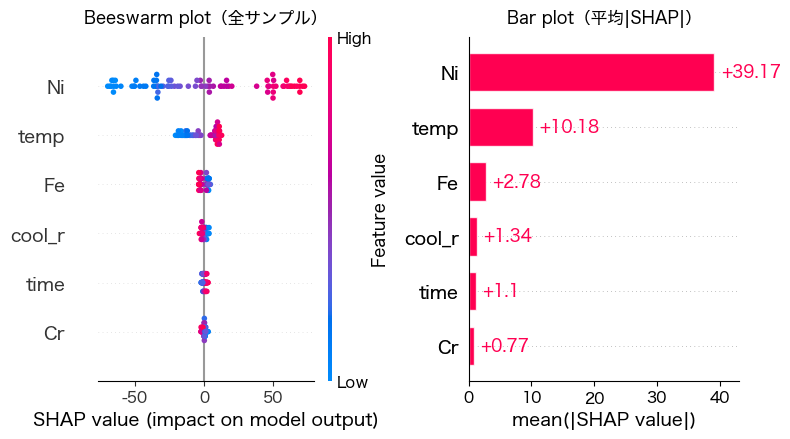

,feature,mean_|SHAP|
1,Ni,39.165
3,temp,10.182
0,Fe,2.782
5,cool_r,1.336
4,time,1.099
2,Cr,0.767


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
shap.plots.beeswarm(shap_values, max_display=10, show=False)
axes[0].set_title("Beeswarm plot（全サンプル）", pad=10)

plt.sca(axes[1])
shap.plots.bar(shap_values, max_display=10, show=False)
axes[1].set_title("Bar plot（平均|SHAP|）", pad=10)

plt.tight_layout()
plt.show()

# SHAP値の数値確認
mean_shap = np.abs(shap_values.values).mean(axis=0)
pd.DataFrame({'feature': feature_cols, 'mean_|SHAP|': mean_shap}).sort_values('mean_|SHAP|', ascending=False).round(3)

## 5. Dependence plot：気になる特徴量を深掘りする

Beeswarmで赤青が混在していた特徴量（非線形性・交互作用の疑い）をDependence plotで確認します。

- 横軸：特徴量の実際の値
- 縦軸：その特徴量のSHAP値（予測値への寄与）
- 色：別の特徴量（交互作用の相手候補）

今回のデモデータには `temp × Ni` の交互作用項を組み込んでいるため、Niをtempで色分けすると交互作用が見えるはずです。

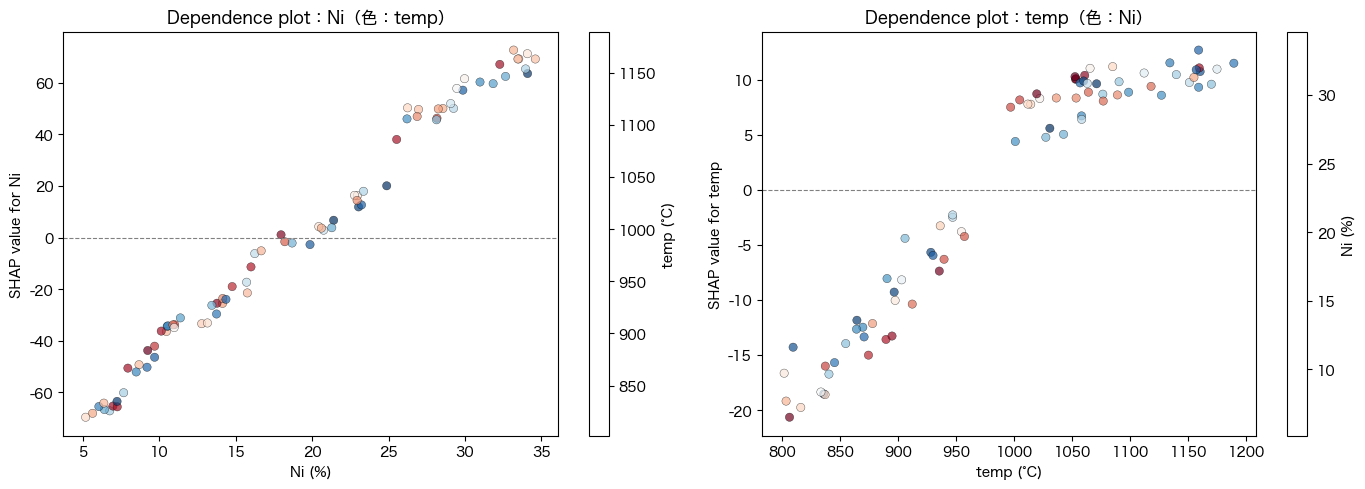

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ni の dependence plot（色：temp）
ni_idx  = feature_cols.index('Ni')
tmp_idx = feature_cols.index('temp')

axes[0].scatter(X[:, ni_idx], shap_values.values[:, ni_idx],
                c=X[:, tmp_idx], cmap='RdBu_r', alpha=0.7, edgecolors='k', linewidths=0.3)
sc = axes[0].scatter(X[:, ni_idx], shap_values.values[:, ni_idx],
                     c=X[:, tmp_idx], cmap='RdBu_r', alpha=0)
plt.colorbar(sc, ax=axes[0], label='temp (°C)')
axes[0].set_xlabel('Ni (%)')
axes[0].set_ylabel('SHAP value for Ni')
axes[0].set_title('Dependence plot：Ni（色：temp）')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)

# temp の dependence plot（色：Ni）
axes[1].scatter(X[:, tmp_idx], shap_values.values[:, tmp_idx],
                c=X[:, ni_idx], cmap='RdBu_r', alpha=0.7, edgecolors='k', linewidths=0.3)
sc2 = axes[1].scatter(X[:, tmp_idx], shap_values.values[:, tmp_idx],
                      c=X[:, ni_idx], cmap='RdBu_r', alpha=0)
plt.colorbar(sc2, ax=axes[1], label='Ni (%)')
axes[1].set_xlabel('temp (°C)')
axes[1].set_ylabel('SHAP value for temp')
axes[1].set_title('Dependence plot：temp（色：Ni）')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

## 6. SHAP局所解釈：Waterfall plot（オプション）

**特定の1サンプルについて「なぜこの予測値になったか」を説明したいときに使います。**

全サンプルに対して毎回確認するものではありません。たとえば「この実験だけ予測が大きく外れた理由を説明したい」「この高性能サンプルがなぜ高いのかを実験者に見せたい」という場面で使います。

- 起点：訓練データ全体の平均予測値（Base value）
- 各特徴量のSHAP値が赤（プラス寄与）または青（マイナス寄与）で積み重なる
- 最終値：そのサンプルのモデル予測値

サンプル#52：実測値=532.5 MPa, 予測値=517.3 MPa
Fe          62.90
Ni          33.18
Cr           3.92
temp      1060.78
time         8.40
cool_r       5.63
Name: 52, dtype: float64


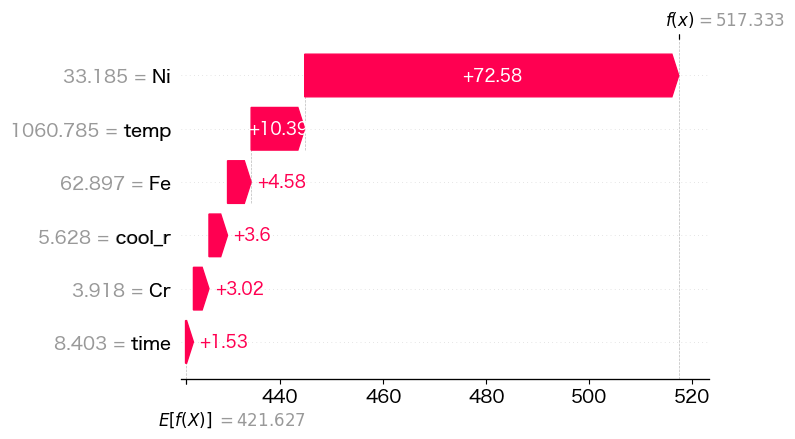

In [9]:
# 引張強度が最も高いサンプルを可視化
idx_high = np.argmax(y_arr)
print(f"サンプル#{idx_high}：実測値={y_arr[idx_high]:.1f} MPa, 予測値={rf.predict(X[idx_high:idx_high+1])[0]:.1f} MPa")
print(df[feature_cols].iloc[idx_high].round(2))

shap.plots.waterfall(shap_values[idx_high], max_display=10, show=False)
plt.tight_layout()
plt.show()

## 7. 落とし穴：多重共線性でSHAP値が分散する

**問題の設定：** Niと強く相関する特徴量 `Ni_ratio`（= Ni / Fe）を追加します。
物理的にはNiそのものが支配的なはずですが、SHAPは相関する2変数に重要度を分散させます。

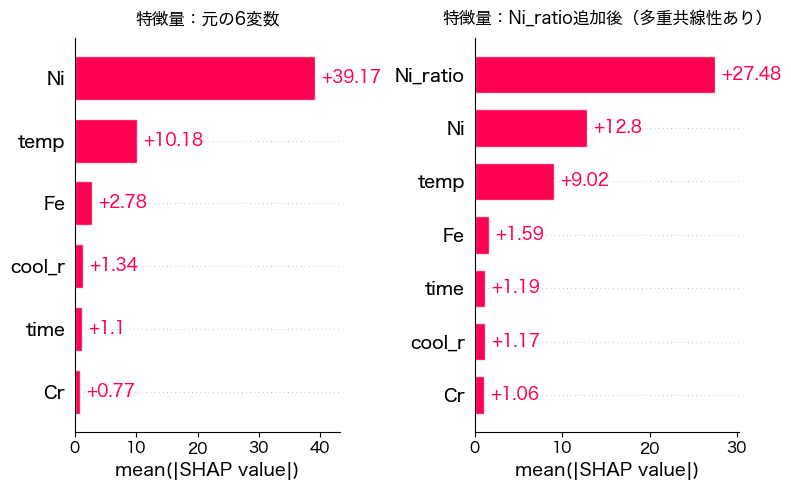

Ni と Ni_ratio の相関係数: 0.986

→ NiのSHAP重要度が分散し、真の支配因子が見えにくくなっていることを確認


In [10]:
# 多重共線性を持つ特徴量を追加
df['Ni_ratio'] = df['Ni'] / df['Fe']   # Niと相関

feature_cols_mc = ['Fe', 'Ni', 'Cr', 'temp', 'time', 'cool_r', 'Ni_ratio']
X_mc = df[feature_cols_mc].values

rf_mc = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
rf_mc.fit(X_mc, y_arr)

X_mc_df = pd.DataFrame(X_mc, columns=feature_cols_mc)
shap_values_mc = shap.TreeExplainer(rf_mc)(X_mc_df, check_additivity=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
shap.plots.bar(shap_values, max_display=8, show=False)
axes[0].set_title("特徴量：元の6変数", pad=10)

plt.sca(axes[1])
shap.plots.bar(shap_values_mc, max_display=8, show=False)
axes[1].set_title("特徴量：Ni_ratio追加後（多重共線性あり）", pad=10)

plt.tight_layout()
plt.show()

# 相関係数確認
print(f"Ni と Ni_ratio の相関係数: {np.corrcoef(df['Ni'], df['Ni_ratio'])[0,1]:.3f}")
print("\n→ NiのSHAP重要度が分散し、真の支配因子が見えにくくなっていることを確認")

## 8. 逆解析①：scipy.optimizeによる単目標最適化

**目標：** 訓練済みRFモデルを使って引張強度を最大化する合金組成・プロセスを求める

**制約条件：**
- Fe + Ni + Cr = 100（組成の閉包制約）
- 各変数の上下限（材料・装置の実操作範囲）

**注意：** 初期値依存性があるため、複数の初期値からマルチスタート最適化を行います。
> **⚠️ RF逆解析の限界：** ランダムフォレストは外挿に弱く、訓練データ範囲外の組成・条件に対して過大・過小評価するリスクがあります。  
> 得られた最適解はあくまで「モデルが最大値を返す点」であり、実際の性能を保証するものではありません。  
> 次のセクション（逆解析②）でGPRの不確実性σを使った安全な最適化を示します。


In [11]:
from scipy.optimize import minimize, Bounds

# 変数：[Fe, Ni, Cr, temp, time, cool_r]
# 目的関数（最小化なのでマイナス）
def objective(x):
    return -rf.predict(x.reshape(1, -1))[0]

# 変数の上下限
bounds = Bounds(
    lb=[50.0, 5.0,  2.0, 800.0,  1.0,  1.0],
    ub=[90.0, 40.0, 20.0, 1200.0, 10.0, 50.0]
)

# 等式制約：Fe + Ni + Cr = 100
constraints = [{'type': 'eq', 'fun': lambda x: x[0] + x[1] + x[2] - 100.0}]

# マルチスタート（10回）
results = []
for seed in range(10):
    rng = np.random.default_rng(seed)
    # 制約を満たす初期値を生成
    ni0  = rng.uniform(5, 35)
    cr0  = rng.uniform(2, 18)
    fe0  = 100 - ni0 - cr0
    x0 = np.array([fe0, ni0, cr0,
                   rng.uniform(800, 1200),
                   rng.uniform(1, 10),
                   rng.uniform(1, 50)])
    res = minimize(objective, x0, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'maxiter': 500, 'ftol': 1e-9})
    if res.success:
        results.append((res.fun, res.x))

results.sort(key=lambda r: r[0])
best_val, best_x = results[0]

print("═" * 50)
print(f"予測最大引張強度: {-best_val:.1f} MPa")
print("═" * 50)
opt_df = pd.DataFrame({
    '変数': feature_cols,
    '最適値': best_x,
    '訓練データ平均': df[feature_cols].mean().values,
    '訓練データ最大': df[feature_cols].max().values
})
print(opt_df.round(2).to_string(index=False))
print(f"\nFe+Ni+Cr = {best_x[0]+best_x[1]+best_x[2]:.2f}%（制約確認）")


# ── 最適解 vs 訓練データ範囲のチェック ──
print("\n--- 最適解 vs 訓練データ範囲 ---")
train_min = df[feature_cols].min().values
train_max = df[feature_cols].max().values
in_range = (best_x >= train_min) & (best_x <= train_max)
for feat, val, lo, hi, ok in zip(feature_cols, best_x, train_min, train_max, in_range):
    flag = "✓" if ok else "⚠️ 範囲外"
    print(f"  {feat:8s}: {val:7.2f}  [{lo:.2f}, {hi:.2f}]  {flag}")


══════════════════════════════════════════════════
予測最大引張強度: 503.3 MPa
══════════════════════════════════════════════════
    変数     最適値  訓練データ平均  訓練データ最大
    Fe   56.53    71.21    90.52
    Ni   33.29    18.98    34.61
    Cr   10.18     9.81    17.77
  temp 1190.50   994.63  1189.20
  time    1.73     5.80     9.91
cool_r   30.76    25.33    49.53

Fe+Ni+Cr = 100.00%（制約確認）

--- 最適解 vs 訓練データ範囲 ---
  Fe      :   56.53  [51.60, 90.52]  ✓
  Ni      :   33.29  [5.17, 34.61]  ✓
  Cr      :   10.18  [2.11, 17.77]  ✓
  temp    : 1190.50  [802.02, 1189.20]  ⚠️ 範囲外
  time    :    1.73  [1.14, 9.91]  ✓
  cool_r  :   30.76  [1.71, 49.53]  ✓


## 9. 逆解析②：GPRのσで外挿リスクを制御する

**問題：** 逆解析アルゴリズムは「モデルが過大評価している外挿領域」をピンポイントで見つけてしまう。
GPRの不確実性σを使い、「σが閾値以下（モデルが自信を持っている領域）でのみ最適化する」ことで外挿リスクを抑制できます。

**ペナルティ方式：** 目的関数に `λ × σ` を足して、不確実性の高い領域を自動的に避けるようにします。

In [12]:
# κ：探索の保守性を制御するパラメータ
# κ=0 → 期待値のみ最大化（大胆）
# κ=2 → μ - 2σ を最大化（保守的）

def gpr_objective(x, kappa=2.0):
    x_sc = scaler.transform(x.reshape(1, -1))
    mu_pred, sigma_pred = gpr.predict(x_sc, return_std=True)
    # μ - κ*σ を最小化（= μ - κ*σ を最大化）
    return -(mu_pred[0] - kappa * sigma_pred[0])

results_gpr = {}
for kappa in [0.0, 1.0, 2.0]:
    best_runs = []
    for seed in range(10):
        rng = np.random.default_rng(seed)
        ni0 = rng.uniform(5, 35)
        cr0 = rng.uniform(2, 18)
        fe0 = 100 - ni0 - cr0
        x0  = np.array([fe0, ni0, cr0,
                        rng.uniform(800, 1200),
                        rng.uniform(1, 10),
                        rng.uniform(1, 50)])
        res = minimize(lambda x: gpr_objective(x, kappa), x0,
                       method='SLSQP', bounds=bounds,
                       constraints=constraints,
                       options={'maxiter': 500})
        if res.success:
            x_sc = scaler.transform(res.x.reshape(1, -1))
            mu, sig = gpr.predict(x_sc, return_std=True)
            best_runs.append((mu[0], sig[0], res.x))
    if best_runs:
        best_runs.sort(key=lambda r: -(r[0] - kappa * r[1]))
        results_gpr[kappa] = best_runs[0]

print(f"{'κ':>5} | {'予測μ (MPa)':>12} | {'不確実性σ':>10} | {'Ni (%)':>8} | {'temp (°C)':>10}")
print("-" * 60)
for kappa, (mu_val, sig_val, x_opt) in results_gpr.items():
    print(f"{kappa:>5.1f} | {mu_val:>12.1f} | {sig_val:>10.3f} | {x_opt[1]:>8.1f} | {x_opt[3]:>10.1f}")

print("\n→ 今回の結果では κ を変えても最適解が境界（Ni上限・temp上限）に張り付いています。")
print("  これは訓練データ範囲の境界自体が最高性能域であるためで、GPR σ 制御の限界を示す例です。")
print("  実務では bounds をより保守的に設定するか、訓練データ外への外挿を明示的に禁止することを推奨します。")

    κ |    予測μ (MPa) |      不確実性σ |   Ni (%) |  temp (°C)
------------------------------------------------------------
  0.0 |        591.8 |     12.996 |     40.0 |     1200.0
  1.0 |        591.7 |     12.910 |     40.0 |     1200.0
  2.0 |        591.3 |     12.620 |     40.0 |     1200.0

→ 今回の結果では κ を変えても最適解が境界（Ni上限・temp上限）に張り付いています。
  これは訓練データ範囲の境界自体が最高性能域であるためで、GPR σ 制御の限界を示す例です。
  実務では bounds をより保守的に設定するか、訓練データ外への外挿を明示的に禁止することを推奨します。


## まとめ

| 手法 | 役割 | 主な出力 |
|:-----|:-----|:--------|
| Waterfall plot | 局所解釈：なぜ**このサンプル**がこの予測値か | 特徴量ごとの±寄与量 |
| Beeswarm plot | 大域解釈：モデル全体でどの特徴量が重要か | 全サンプルのSHAP分布 |
| Dependence plot | 非線形・交互作用の可視化 | 特徴量×SHAP値の散布図 |
| 多重共線性デモ | 落とし穴：相関特徴量でSHAP値が分散 | 重要度の誤帰属を確認 |
| scipy.optimize | 単目標逆解析（組成制約あり） | 最適条件の候補リスト |
| GPR + σ制御 | 外挿リスクを抑えた安全な逆解析 | κによる保守性のトレードオフ |

**次のステップ（Zenn記事）**：
各可視化の「読み方」とドメイン知識との紐付け方、多目標最適化（pymoo NSGA-II）について詳しく解説します。